In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

In [3]:
url = "https://data.melbourne.vic.gov.au/api/v2/catalog/datasets/pedestrian-counting-system-past-hour-counts-per-minute/exports/csv?delimiter=%2C"
print("Downloading latest past-hour pedestrian data...")
df = pd.read_csv(url)
print(f"Downloaded {len(df):,} rows")
df.head()

Downloaded 50,561 rows


,location_id,sensing_datetime,sensing_date,sensing_time,direction_1,direction_2,total_of_directions
0,8,2026-08-03T11:34:00+00:00,2026-08-03,21:34,0,1,1
1,29,2026-08-03T11:34:00+00:00,2026-08-03,21:34,0,4,4
2,35,2026-08-03T11:34:00+00:00,2026-08-03,21:34,2,2,4
3,62,2026-08-03T11:34:00+00:00,2026-08-03,21:34,4,1,5
4,86,2026-08-03T11:34:00+00:00,2026-08-03,21:34,0,1,1


In [5]:

print("BASIC INFO")

print(df.info())
print("\nShape:", df.shape)
print("\nColumn names:", df.columns.tolist())

print("\n")
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n")
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df.describe(include='all'))

print("\n")
print("SAMPLE OF UNIQUE LOCATION IDs")
print("="*60)
print(f"Number of unique sensors: {df['location_id'].nunique()}")
print(df['location_id'].unique()[:20])

BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50561 entries, 0 to 50560
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   location_id          50561 non-null  int64 
 1   sensing_datetime     50561 non-null  object
 2   sensing_date         50561 non-null  object
 3   sensing_time         50561 non-null  object
 4   direction_1          50561 non-null  int64 
 5   direction_2          50561 non-null  int64 
 6   total_of_directions  50561 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 2.7+ MB
None

Shape: (50561, 7)

Column names: ['location_id', 'sensing_datetime', 'sensing_date', 'sensing_time', 'direction_1', 'direction_2', 'total_of_directions']


MISSING VALUES
location_id            0
sensing_datetime       0
sensing_date           0
sensing_time           0
direction_1            0
direction_2            0
total_of_directions    0
dtype: int64


DESCRIPTIVE STATISTICS


In [6]:

df['location_id'] = df['location_id'].astype(int)


df['sensing_datetime'] = pd.to_datetime(df['sensing_datetime'], utc=True)
df['sensing_datetime'] = df['sensing_datetime'].dt.tz_convert('Australia/Melbourne')

for col in ['direction_1', 'direction_2', 'total_of_directions']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)


df = df.dropna(subset=['location_id', 'sensing_datetime'])

df = df[(df['direction_1'] >= 0) & (df['direction_2'] >= 0)]

before = len(df)
df = df.drop_duplicates(subset=['location_id', 'sensing_datetime'], keep='last')
print(f"Removed {before - len(df)} duplicate rows")


df = df.sort_values(['location_id', 'sensing_datetime']).reset_index(drop=True)

print("\nCleaned dataset shape:", df.shape)
df.head()

Removed 22 duplicate rows

Cleaned dataset shape: (50539, 7)


,location_id,sensing_datetime,sensing_date,sensing_time,direction_1,direction_2,total_of_directions
0,1,2026-08-03 00:00:00+10:00,2026-08-03,00:00,4,0,4
1,1,2026-08-03 00:05:00+10:00,2026-08-03,00:05,1,0,1
2,1,2026-08-03 00:06:00+10:00,2026-08-03,00:06,0,1,1
3,1,2026-08-03 00:07:00+10:00,2026-08-03,00:07,0,2,2
4,1,2026-08-03 00:08:00+10:00,2026-08-03,00:08,0,1,1


In [7]:
df['date'] = df['sensing_datetime'].dt.date
df['hour'] = df['sensing_datetime'].dt.hour
df['minute'] = df['sensing_datetime'].dt.minute
df['day_of_week'] = df['sensing_datetime'].dt.day_name()
df['is_weekend'] = df['sensing_datetime'].dt.dayofweek >= 5

#
df['total_count'] = df['direction_1'] + df['direction_2']


def classify_density(count):
    if count <= 50:
        return 'Low'
    elif count <= 150:
        return 'Medium'
    else:
        return 'High'

df['density_level'] = df['total_count'].apply(classify_density)
df['rolling_5min'] = (
    df.groupby('location_id')['total_count']
      .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

print("Feature engineering complete.")
df[['location_id', 'sensing_datetime', 'total_count', 'density_level', 'rolling_5min']].head(10)

Feature engineering complete.


,location_id,sensing_datetime,total_count,density_level,rolling_5min
0,1,2026-08-03 00:00:00+10:00,4,Low,4.0
1,1,2026-08-03 00:05:00+10:00,1,Low,2.5
2,1,2026-08-03 00:06:00+10:00,1,Low,2.0
3,1,2026-08-03 00:07:00+10:00,2,Low,2.0
4,1,2026-08-03 00:08:00+10:00,1,Low,1.8
5,1,2026-08-03 00:09:00+10:00,2,Low,1.4
6,1,2026-08-03 00:11:00+10:00,1,Low,1.4
7,1,2026-08-03 00:14:00+10:00,3,Low,1.8
8,1,2026-08-03 00:16:00+10:00,1,Low,1.6
9,1,2026-08-03 00:17:00+10:00,1,Low,1.6


In [8]:
print("Density Level Distribution:")
print(df['density_level'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


top_sensors = (
    df.groupby('location_id')['total_count']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print("\nTop 10 busiest sensors (total pedestrians in last hour):")
print(top_sensors)

avg_by_minute = df.groupby('minute')['total_count'].mean()

Density Level Distribution:
density_level
Low       95.2%
Medium     4.3%
High       0.4%
Name: proportion, dtype: object

Top 10 busiest sensors (total pedestrians in last hour):
location_id
59     32692
41     28030
66     26784
4      26617
3      23845
84     20948
181    20674
24     20590
35     19452
5      16663
Name: total_count, dtype: int64


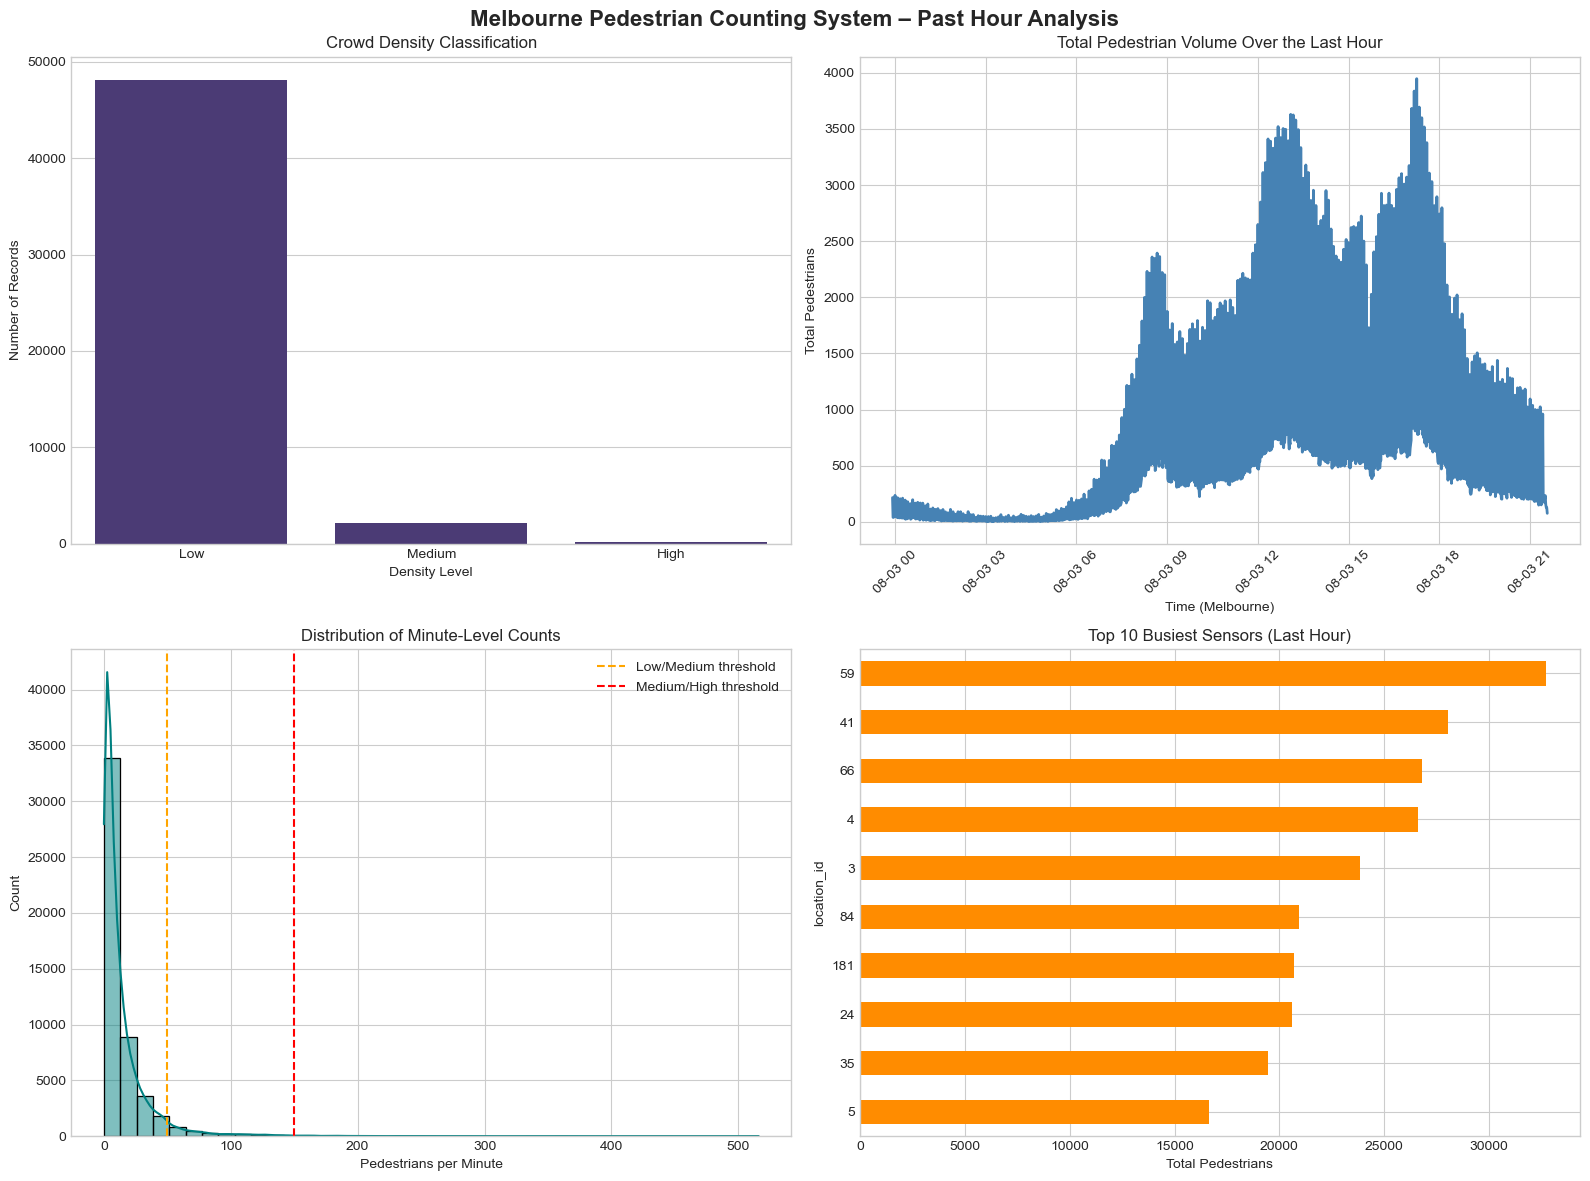

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Melbourne Pedestrian Counting System – Past Hour Analysis', fontsize=16, fontweight='bold')

sns.countplot(data=df, x='density_level', order=['Low', 'Medium', 'High'], ax=axes[0,0])
axes[0,0].set_title('Crowd Density Classification')
axes[0,0].set_xlabel('Density Level')
axes[0,0].set_ylabel('Number of Records')


time_series = df.groupby('sensing_datetime')['total_count'].sum()
axes[0,1].plot(time_series.index, time_series.values, color='steelblue', linewidth=2)
axes[0,1].set_title('Total Pedestrian Volume Over the Last Hour')
axes[0,1].set_xlabel('Time (Melbourne)')
axes[0,1].set_ylabel('Total Pedestrians')
axes[0,1].tick_params(axis='x', rotation=45)


sns.histplot(df['total_count'], bins=40, kde=True, ax=axes[1,0], color='teal')
axes[1,0].set_title('Distribution of Minute-Level Counts')
axes[1,0].set_xlabel('Pedestrians per Minute')
axes[1,0].axvline(50, color='orange', linestyle='--', label='Low/Medium threshold')
axes[1,0].axvline(150, color='red', linestyle='--', label='Medium/High threshold')
axes[1,0].legend()


top_sensors.plot(kind='barh', ax=axes[1,1], color='darkorange')
axes[1,1].set_title('Top 10 Busiest Sensors (Last Hour)')
axes[1,1].set_xlabel('Total Pedestrians')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

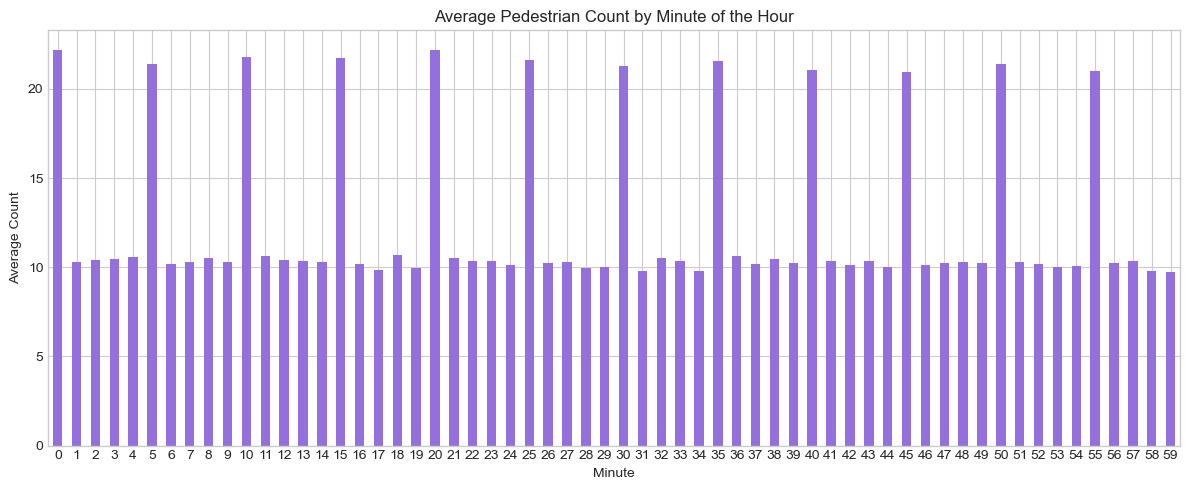

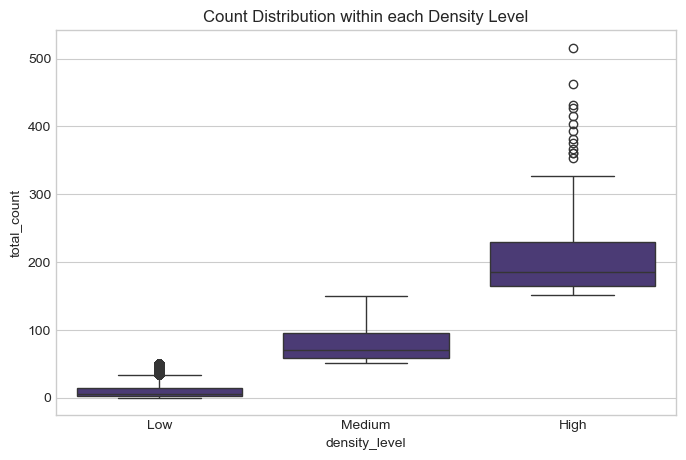

In [11]:

plt.figure(figsize=(12, 5))
avg_by_minute.plot(kind='bar', color='mediumpurple')
plt.title('Average Pedestrian Count by Minute of the Hour')
plt.xlabel('Minute')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='density_level', y='total_count', order=['Low', 'Medium', 'High'])
plt.title('Count Distribution within each Density Level')
plt.show()


In [13]:
clean_df = df[[
    'location_id',
    'sensing_datetime',
    'direction_1',
    'direction_2',
    'total_count',
    'density_level',
    'rolling_5min',
    'hour',
    'minute',
    'day_of_week',
    'is_weekend'
]].copy()


clean_df.to_csv('pedestrian_past_hour_clean.csv', index=False)
print("Clean dataset saved as 'pedestrian_past_hour_clean.csv'")
print(f"Final shape: {clean_df.shape}")
clean_df.head()

Clean dataset saved as 'pedestrian_past_hour_clean.csv'
Final shape: (50539, 11)


,location_id,sensing_datetime,direction_1,direction_2,total_count,density_level,rolling_5min,hour,minute,day_of_week,is_weekend
0,1,2026-08-03 00:00:00+10:00,4,0,4,Low,4.0,0,0,Monday,False
1,1,2026-08-03 00:05:00+10:00,1,0,1,Low,2.5,0,5,Monday,False
2,1,2026-08-03 00:06:00+10:00,0,1,1,Low,2.0,0,6,Monday,False
3,1,2026-08-03 00:07:00+10:00,0,2,2,Low,2.0,0,7,Monday,False
4,1,2026-08-03 00:08:00+10:00,0,1,1,Low,1.8,0,8,Monday,False


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

print("Libraries loaded successfully")

Libraries loaded successfully


In [17]:

url = "https://data.melbourne.vic.gov.au/api/v2/catalog/datasets/pedestrian-counting-system-sensor-locations/exports/csv?delimiter=,"

df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()


Shape: (134, 12)

Columns:
['location_id', 'sensor_description', 'sensor_name', 'installation_date', 'note', 'location_type', 'status', 'direction_1', 'direction_2', 'latitude', 'longitude', 'location']


,location_id,sensor_description,sensor_name,installation_date,note,location_type,status,direction_1,direction_2,latitude,longitude,location
0,3,Melbourne Central,Swa295_T,2009-03-25,NaN,Outdoor,A,North,South,-37.811015,144.964295,"-37.81101524, 144.96429485"
1,5,Princes Bridge,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"
2,9,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
3,11,Docklands Waterfront City Building Side,WatCit_T,2009-01-20,Device has been replaced with new sensor on 22...,Outdoor,A,East,West,-37.815667,144.939744,"-37.81566651, 144.93974366"
4,12,New Quay,NewQ_T,2009-01-21,NaN,Outdoor,A,East,West,-37.814580,144.942924,"-37.81457988, 144.94292398"


In [18]:
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 60)
print("CATEGORICAL VALUE COUNTS")
print("=" * 60)
for col in ['status', 'location_type', 'direction_1', 'direction_2']:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))

DATASET OVERVIEW
Rows: 134, Columns: 12

Data types:
location_id             int64
sensor_description     object
sensor_name            object
installation_date      object
note                   object
location_type          object
status                 object
direction_1            object
direction_2            object
latitude              float64
longitude             float64
location               object
dtype: object

Missing values:
location_id            0
sensor_description     0
sensor_name            0
installation_date      1
note                  96
location_type          0
status                 0
direction_1           34
direction_2           34
latitude               0
longitude              0
location               0
dtype: int64

Duplicate rows: 0

Memory usage: 0.07 MB

CATEGORICAL VALUE COUNTS

status:
status
A    134
Name: count, dtype: int64

location_type:
location_type
Outdoor    100
Indoor      34
Name: count, dtype: int64

direction_1:
direction_1
North    53


In [19]:
df.columns = df.columns.str.strip().str.lower()
df['location_id'] = pd.to_numeric(df['location_id'], errors='coerce').astype('Int64')
df['latitude']    = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude']   = pd.to_numeric(df['longitude'], errors='coerce')
df['installation_date'] = pd.to_datetime(df['installation_date'], errors='coerce')
text_cols = ['sensor_description', 'sensor_name', 'note', 'location_type', 
             'status', 'direction_1', 'direction_2']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(['nan', 'None', ''], np.nan)
if 'location' in df.columns:
 
    def parse_location(val):
        try:
            if pd.isna(val):
                return np.nan, np.nan
            parts = str(val).replace('"', '').split(',')
            return float(parts[0].strip()), float(parts[1].strip())
        except:
            return np.nan, np.nan
    

    mask = df['latitude'].isna() | df['longitude'].isna()
    if mask.any():
        parsed = df.loc[mask, 'location'].apply(parse_location)
        df.loc[mask, 'latitude']  = parsed.apply(lambda x: x[0])
        df.loc[mask, 'longitude'] = parsed.apply(lambda x: x[1])
df = df.dropna(how='all')
df = df.loc[:, ~df.columns.duplicated()]
df['has_note'] = df['note'].notna()
df['year_installed'] = df['installation_date'].dt.year
df['is_active'] = df['status'].str.upper() == 'A'
df['sensor_age_years'] = (pd.Timestamp.now() - df['installation_date']).dt.days / 365.25

print("Cleaning complete")
print(f"New shape: {df.shape}")
df.info()

Cleaning complete
New shape: (134, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   location_id         134 non-null    Int64         
 1   sensor_description  134 non-null    object        
 2   sensor_name         134 non-null    object        
 3   installation_date   133 non-null    datetime64[ns]
 4   note                38 non-null     object        
 5   location_type       134 non-null    object        
 6   status              134 non-null    object        
 7   direction_1         100 non-null    object        
 8   direction_2         100 non-null    object        
 9   latitude            134 non-null    float64       
 10  longitude           134 non-null    float64       
 11  location            134 non-null    object        
 12  has_note            134 non-null    bool          
 13  year_instal

In [20]:
CBD_BOUNDS = {
    'lat_min': -37.825,
    'lat_max': -37.805,
    'lon_min': 144.955,
    'lon_max': 144.980
}

df['in_cbd'] = (
    (df['latitude']  >= CBD_BOUNDS['lat_min']) &
    (df['latitude']  <= CBD_BOUNDS['lat_max']) &
    (df['longitude'] >= CBD_BOUNDS['lon_min']) &
    (df['longitude'] <= CBD_BOUNDS['lon_max'])
)

print(f"Sensors in approximate CBD: {df['in_cbd'].sum()} / {len(df)}")


df['directions'] = df['direction_1'].fillna('') + ' / ' + df['direction_2'].fillna('')
df['directions'] = df['directions'].str.strip(' /')


status_map = {'A': 'Active', 'I': 'Inactive', 'R': 'Removed'}  # adjust if other codes appear
df['status_label'] = df['status'].map(status_map).fillna(df['status'])


keep_cols = [
    'location_id', 'sensor_name', 'sensor_description', 
    'installation_date', 'year_installed', 'sensor_age_years',
    'status', 'status_label', 'is_active', 'location_type',
    'direction_1', 'direction_2', 'directions',
    'latitude', 'longitude', 'in_cbd', 'note', 'has_note'
]
df_clean = df[[c for c in keep_cols if c in df.columns]].copy()

print("\nCleaned dataframe preview:")
df_clean.head()

Sensors in approximate CBD: 89 / 134

Cleaned dataframe preview:


,location_id,sensor_name,sensor_description,installation_date,year_installed,sensor_age_years,status,status_label,is_active,location_type,direction_1,direction_2,directions,latitude,longitude,in_cbd,note,has_note
0,3,Swa295_T,Melbourne Central,2009-03-25,2009.0,17.360712,A,Active,True,Outdoor,North,South,North / South,-37.811015,144.964295,True,NaN,False
1,5,PriNW_T,Princes Bridge,2009-03-26,2009.0,17.357974,A,Active,True,Outdoor,North,South,North / South,-37.818742,144.967877,True,Replace with: 00:6e:02:01:9e:54,True
2,9,Col700_T,Southern Cross Station,2009-03-23,2009.0,17.366188,A,Active,True,Outdoor,East,West,East / West,-37.819830,144.951026,False,NaN,False
3,11,WatCit_T,Docklands Waterfront City Building Side,2009-01-20,2009.0,17.535934,A,Active,True,Outdoor,East,West,East / West,-37.815667,144.939744,False,Device has been replaced with new sensor on 22...,True
4,12,NewQ_T,New Quay,2009-01-21,2009.0,17.533196,A,Active,True,Outdoor,East,West,East / West,-37.814580,144.942924,False,NaN,False


In [21]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df_clean.describe(include='all').T)

print("\nActive vs Inactive:")
print(df_clean['status_label'].value_counts())

print("\nLocation type:")
print(df_clean['location_type'].value_counts())

print("\nInstallation year distribution:")
print(df_clean['year_installed'].value_counts().sort_index())

SUMMARY STATISTICS
                    count unique                                            top  freq                           mean  \
location_id         134.0   <NA>                                           <NA>  <NA>                      90.753731   
sensor_name           134    131                                    BirBridge_T     2                            NaN   
sensor_description    134    133  Birrarung Marr East - Batman Ave Bridge Entry     2                            NaN   
installation_date     133    NaN                                            NaN   NaN  2019-02-27 13:42:51.428571392   
year_installed      133.0    NaN                                            NaN   NaN                     2018.62406   
sensor_age_years    133.0    NaN                                            NaN   NaN                         7.4317   
status                134      1                                              A   134                            NaN   
status_label         

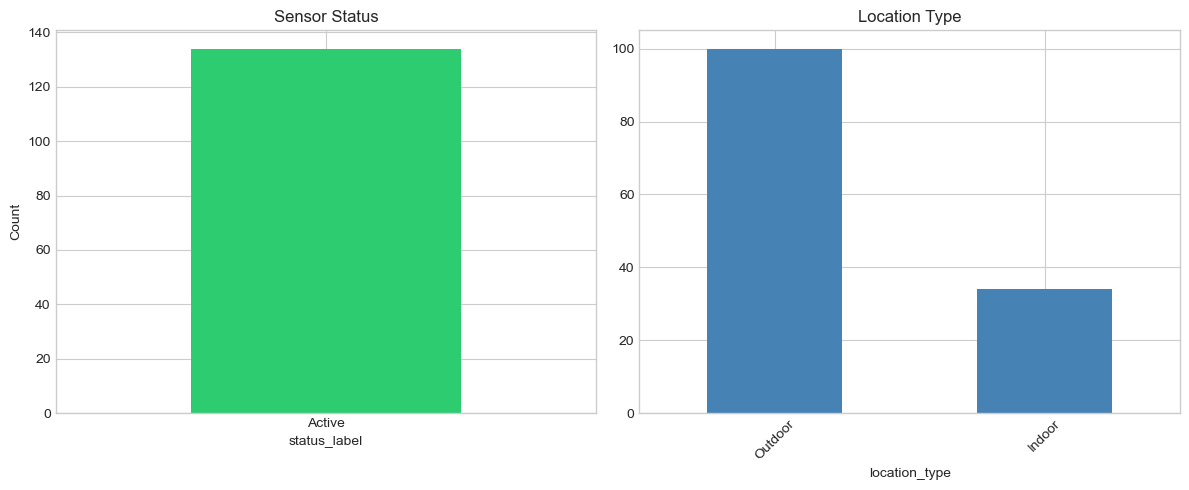

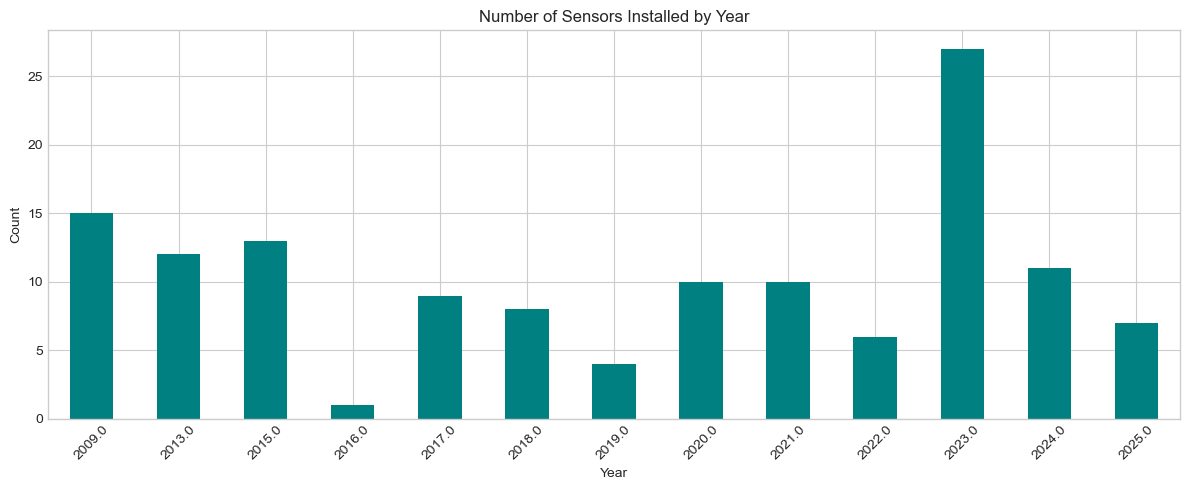

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_clean['status_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#95a5a6']
)
axes[0].set_title('Sensor Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_clean['location_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='steelblue'
)
axes[1].set_title('Location Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 5))
yearly = df_clean['year_installed'].value_counts().sort_index()
yearly.plot(kind='bar', color='teal')
plt.title('Number of Sensors Installed by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

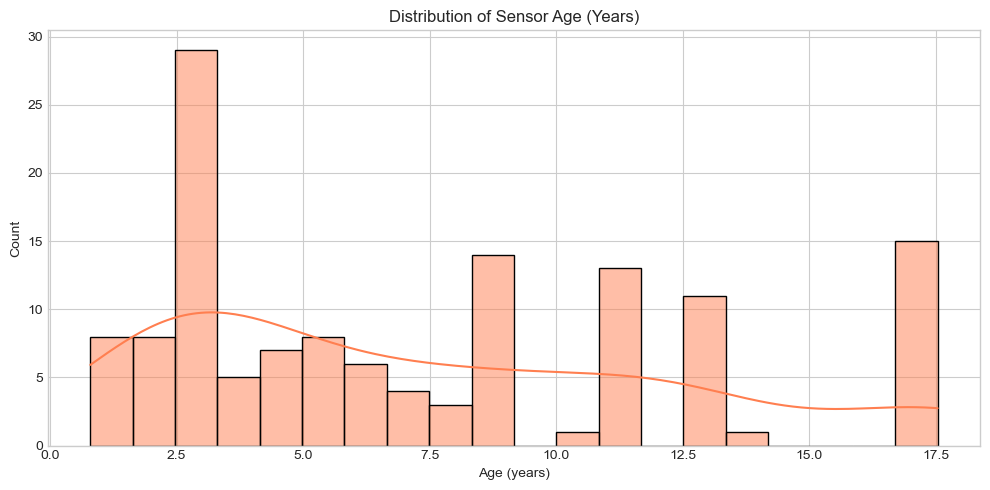

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['sensor_age_years'].dropna(), bins=20, kde=True, color='coral')
plt.title('Distribution of Sensor Age (Years)')
plt.xlabel('Age (years)')
plt.tight_layout()
plt.show()

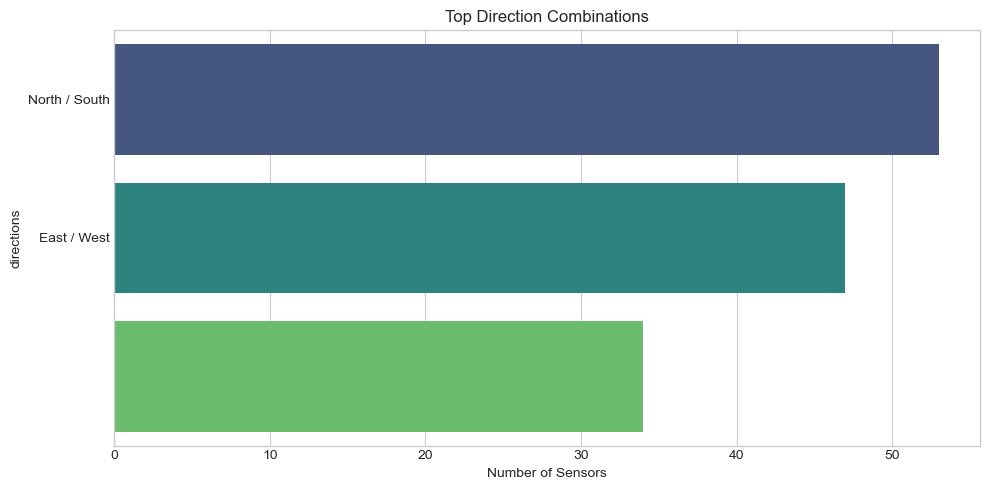

In [25]:

plt.figure(figsize=(10, 5))
dir_counts = df_clean['directions'].value_counts().head(10)
sns.barplot(x=dir_counts.values, y=dir_counts.index, palette='viridis')
plt.title('Top Direction Combinations')
plt.xlabel('Number of Sensors')
plt.tight_layout()
plt.show()

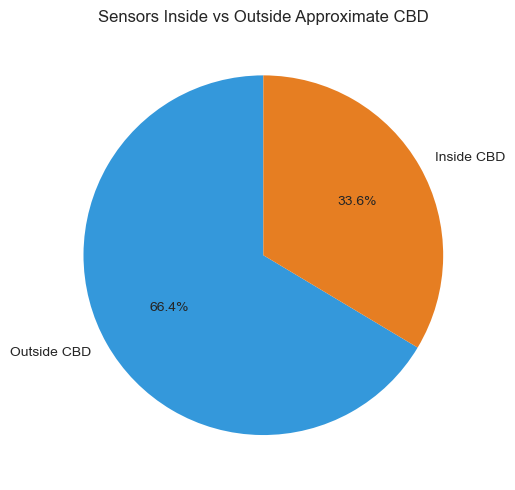

In [26]:

plt.figure(figsize=(6, 5))
df_clean['in_cbd'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', labels=['Outside CBD', 'Inside CBD'],
    colors=['#3498db', '#e67e22'], startangle=90
)
plt.title('Sensors Inside vs Outside Approximate CBD')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [27]:

m = folium.Map(location=[-37.8136, 144.9631], zoom_start=14, tiles='CartoDB positron')


def get_colour(row):
    if row['is_active']:
        return 'green'
    return 'red'


marker_cluster = MarkerCluster().add_to(m)

for _, row in df_clean.dropna(subset=['latitude', 'longitude']).iterrows():
    popup_html = f"""
    <b>{row['sensor_description']}</b><br>
    ID: {row['location_id']}<br>
    Name: {row['sensor_name']}<br>
    Status: {row['status_label']}<br>
    Installed: {row['installation_date'].date() if pd.notna(row['installation_date']) else 'N/A'}<br>
    Directions: {row['directions']}<br>
    Note: {row['note'] if pd.notna(row['note']) else 'None'}
    """
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color=get_colour(row),
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=row['sensor_description']
    ).add_to(marker_cluster)

folium.Rectangle(
    bounds=[[CBD_BOUNDS['lat_min'], CBD_BOUNDS['lon_min']],
            [CBD_BOUNDS['lat_max'], CBD_BOUNDS['lon_max']]],
    color='orange',
    fill=False,
    weight=2,
    popup='Approximate CBD boundary'
).add_to(m)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
            background: white; padding: 10px; border: 2px solid grey; border-radius: 5px;">
    <b>Sensor Status</b><br>
    <i style="background:green; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> Active<br>
    <i style="background:red; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> Inactive / Other
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m

In [28]:
df_cbd = df_clean[df_clean['in_cbd']].copy()
print(f"CBD sensors: {len(df_cbd)}")
print(df_cbd[['location_id', 'sensor_description', 'status_label', 'latitude', 'longitude']].head(10))
print("Sensor locations are now clean and ready to be joined on 'location_id'")
df_clean.to_csv('melbourne_pedestrian_sensors_clean.csv', index=False)
df_cbd.to_csv('melbourne_pedestrian_sensors_cbd_only.csv', index=False)
print("Files saved.")

CBD sensors: 89
    location_id                     sensor_description status_label   latitude   longitude
0             3                      Melbourne Central       Active -37.811015  144.964295
1             5                         Princes Bridge       Active -37.818742  144.967877
5            14                       Sandridge Bridge       Active -37.820112  144.962919
6            18                  Collins Place (North)       Active -37.813449  144.973054
7            19          Chinatown-Swanston St (North)       Active -37.812372  144.965507
8            20         Chinatown-Lt Bourke St (South)       Active -37.811729  144.968247
9            27                      QV Market-Peel St       Active -37.806069  144.956447
10           35                    Southbank Promenade       Active -37.820187  144.965085
11           41         Flinders La-Swanston St (West)       Active -37.816686  144.966897
15           47  Melbourne Central-Elizabeth St (East)       Active -37.81

In [29]:
BASE_URL = (
    "https://data.melbourne.vic.gov.au/api/v2/catalog/datasets/"
    "pedestrian-counting-system-monthly-counts-per-hour/exports/csv"
)
params = {
    "delimiter": ",",
    "where": "sensing_date >= '2024-01-01'", 
    
}

# Build query string
from urllib.parse import urlencode
url = BASE_URL + "?" + urlencode(params)

print("Downloading data (this may take 1–3 minutes depending on range)...")
df = pd.read_csv(url, low_memory=False)

print(f"Shape: {df.shape}")
print(f"Date range: {df['sensing_date'].min()} → {df['sensing_date'].max()}")
df.head()

Shape: (1613233, 9)
Date range: 2024-08-04 → 2026-08-03


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,143320260803,143,2026-08-03,3,7,4,11,Spencer_T,"-37.821728, 144.95557015"
1,59220260803,59,2026-08-03,2,23,14,37,RMIT_T,"-37.80825648, 144.96304859"
2,69120260803,69,2026-08-03,1,2,4,6,FLDegC_T,"-37.81687226, 144.96559144"
3,161320260803,161,2026-08-03,3,2,1,3,BirArt1109_T,"-37.81851276, 144.97131336"
4,75320260803,75,2026-08-03,3,1,1,2,SprFli_T,"-37.81515276, 144.97467661"


In [30]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print(f"Memory        : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum():,}")

print("\n" + "=" * 70)
print("BASIC VALUE RANGES")
print("=" * 70)
print(f"location_id unique : {df['location_id'].nunique()}")
print(f"sensor_name unique : {df['sensor_name'].nunique()}")
print(f"hourday range      : {df['hourday'].min()} – {df['hourday'].max()}")
print(f"pedestriancount    : min={df['pedestriancount'].min()}, "
      f"max={df['pedestriancount'].max()}, mean={df['pedestriancount'].mean():.1f}")

DATASET OVERVIEW
Rows          : 1,613,233
Columns       : 9
Memory        : 365.6 MB

Dtypes:
id                  int64
location_id         int64
sensing_date       object
hourday             int64
direction_1         int64
direction_2         int64
pedestriancount     int64
sensor_name        object
location           object
dtype: object

Missing values:
id                     0
location_id            0
sensing_date           0
hourday                0
direction_1            0
direction_2            0
pedestriancount        0
sensor_name        25593
location           25593
dtype: int64

Duplicate rows: 0

BASIC VALUE RANGES
location_id unique : 103
sensor_name unique : 97
hourday range      : 0 – 23
pedestriancount    : min=0, max=11113, mean=393.9


In [31]:

df.columns = df.columns.str.strip().str.lower()


df['location_id']      = pd.to_numeric(df['location_id'], errors='coerce').astype('Int64')
df['hourday']          = pd.to_numeric(df['hourday'], errors='coerce').astype('Int64')
df['direction_1']      = pd.to_numeric(df['direction_1'], errors='coerce').fillna(0).astype(int)
df['direction_2']      = pd.to_numeric(df['direction_2'], errors='coerce').fillna(0).astype(int)
df['pedestriancount']  = pd.to_numeric(df['pedestriancount'], errors='coerce').fillna(0).astype(int)
df['sensing_date']     = pd.to_datetime(df['sensing_date'], errors='coerce')


df['datetime'] = df['sensing_date'] + pd.to_timedelta(df['hourday'], unit='h')


df = df.dropna(subset=['sensing_date', 'location_id', 'hourday'])


df = df[(df['hourday'] >= 0) & (df['hourday'] <= 23)]


df['dir_sum'] = df['direction_1'] + df['direction_2']
mismatch = (df['pedestriancount'] != df['dir_sum']).sum()
print(f"Records where pedestriancount ≠ direction_1 + direction_2: {mismatch:,}")


print(f"\nCleaned shape: {df.shape}")
df.info()

Records where pedestriancount ≠ direction_1 + direction_2: 0

Cleaned shape: (1613233, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1613233 entries, 0 to 1613232
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   id               1613233 non-null  int64         
 1   location_id      1613233 non-null  Int64         
 2   sensing_date     1613233 non-null  datetime64[ns]
 3   hourday          1613233 non-null  Int64         
 4   direction_1      1613233 non-null  int64         
 5   direction_2      1613233 non-null  int64         
 6   pedestriancount  1613233 non-null  int64         
 7   sensor_name      1587640 non-null  object        
 8   location         1587640 non-null  object        
 9   datetime         1613233 non-null  datetime64[ns]
 10  dir_sum          1613233 non-null  int64         
dtypes: Int64(2), datetime64[ns](2), int64(5), object(2)
memory usage: 138.5+ MB


In [32]:

df['year']        = df['sensing_date'].dt.year
df['month']       = df['sensing_date'].dt.month
df['day']         = df['sensing_date'].dt.day
df['dayofweek']   = df['sensing_date'].dt.dayofweek         
df['day_name']    = df['sensing_date'].dt.day_name()
df['is_weekend']  = df['dayofweek'] >= 5
df['week']        = df['sensing_date'].dt.isocalendar().week.astype(int)
df['quarter']     = df['sensing_date'].dt.quarter


def time_bucket(h):
    if 0 <= h < 6:   return 'Night (00-06)'
    if 6 <= h < 10:  return 'Morning Peak (06-10)'
    if 10 <= h < 15: return 'Midday (10-15)'
    if 15 <= h < 19: return 'Evening Peak (15-19)'
    return 'Late Evening (19-24)'

df['time_bucket'] = df['hourday'].apply(time_bucket)


df['is_peak'] = df['hourday'].isin([7, 8, 9, 16, 17, 18])


df['log_count'] = np.log1p(df['pedestriancount'])

print("Feature engineering complete")
df[['sensing_date', 'hourday', 'day_name', 'time_bucket', 'is_weekend', 'pedestriancount']].head()

Feature engineering complete


,sensing_date,hourday,day_name,time_bucket,is_weekend,pedestriancount
0,2026-08-03,3,Monday,Night (00-06),False,11
1,2026-08-03,2,Monday,Night (00-06),False,37
2,2026-08-03,1,Monday,Night (00-06),False,6
3,2026-08-03,3,Monday,Night (00-06),False,3
4,2026-08-03,3,Monday,Night (00-06),False,2


In [33]:
print("=" * 70)
print("KEY STATISTICS")
print("=" * 70)

print("\nTop 10 busiest sensors (total counts in period):")
print(df.groupby('sensor_name')['pedestriancount']
        .sum()
        .sort_values(ascending=False)
        .head(10))

print("\nAverage hourly count by day of week:")
print(df.groupby('day_name')['pedestriancount']
        .mean()
        .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']))

print("\nAverage hourly count by time bucket:")
print(df.groupby('time_bucket')['pedestriancount'].mean().sort_values(ascending=False))

KEY STATISTICS

Top 10 busiest sensors (total counts in period):
sensor_name
Swa123_T    26380993
Swa31       25543529
SouthB_T    23241680
QVN_T       21270557
ElFi_T      21070406
Swa295_T    19750031
FliS_T      19508232
PriNW_T     19091797
Eli250_T    15662218
Col620_T    15655602
Name: pedestriancount, dtype: int64

Average hourly count by day of week:
day_name
Monday       352.964982
Tuesday      390.013011
Wednesday    397.938134
Thursday     415.841973
Friday       424.744140
Saturday     423.635958
Sunday       351.943575
Name: pedestriancount, dtype: float64

Average hourly count by time bucket:
time_bucket
Evening Peak (15-19)    721.555249
Midday (10-15)          624.141847
Late Evening (19-24)    358.117791
Morning Peak (06-10)    269.393734
Night (00-06)            45.369860
Name: pedestriancount, dtype: float64


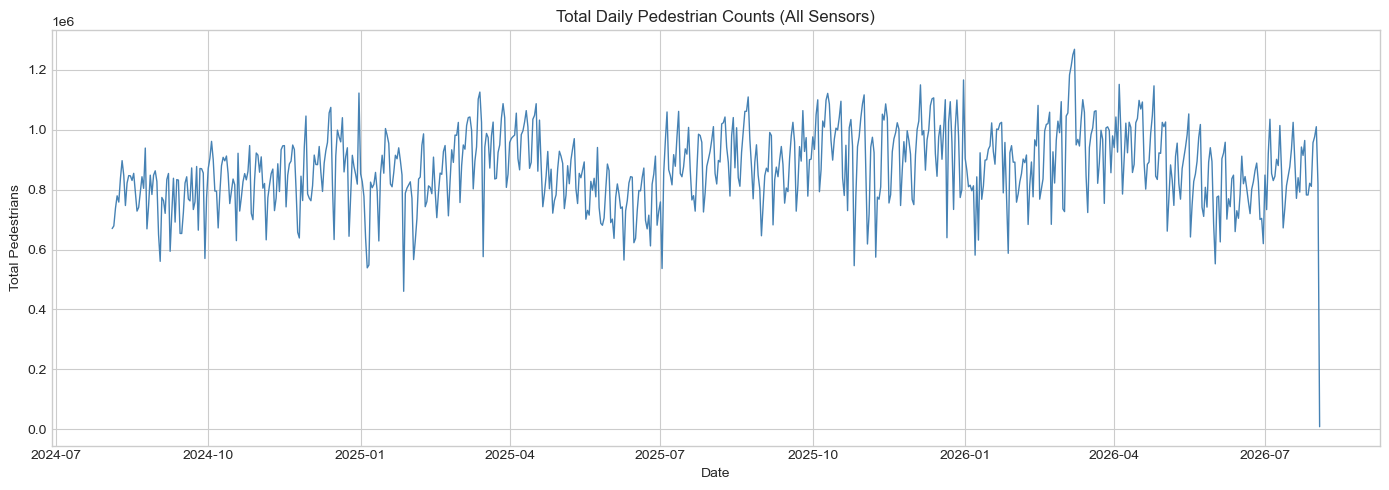

In [34]:

daily = df.groupby('sensing_date')['pedestriancount'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily['sensing_date'], daily['pedestriancount'], linewidth=1, color='steelblue')
plt.title('Total Daily Pedestrian Counts (All Sensors)')
plt.xlabel('Date')
plt.ylabel('Total Pedestrians')
plt.tight_layout()


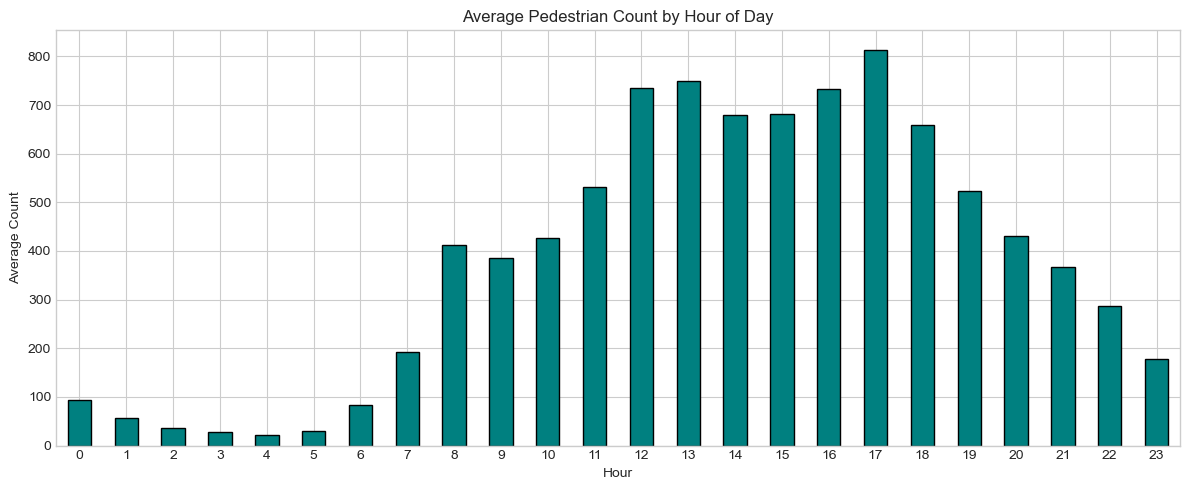

In [35]:
hourly_avg = df.groupby('hourday')['pedestriancount'].mean()

plt.figure(figsize=(12, 5))
hourly_avg.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Pedestrian Count by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

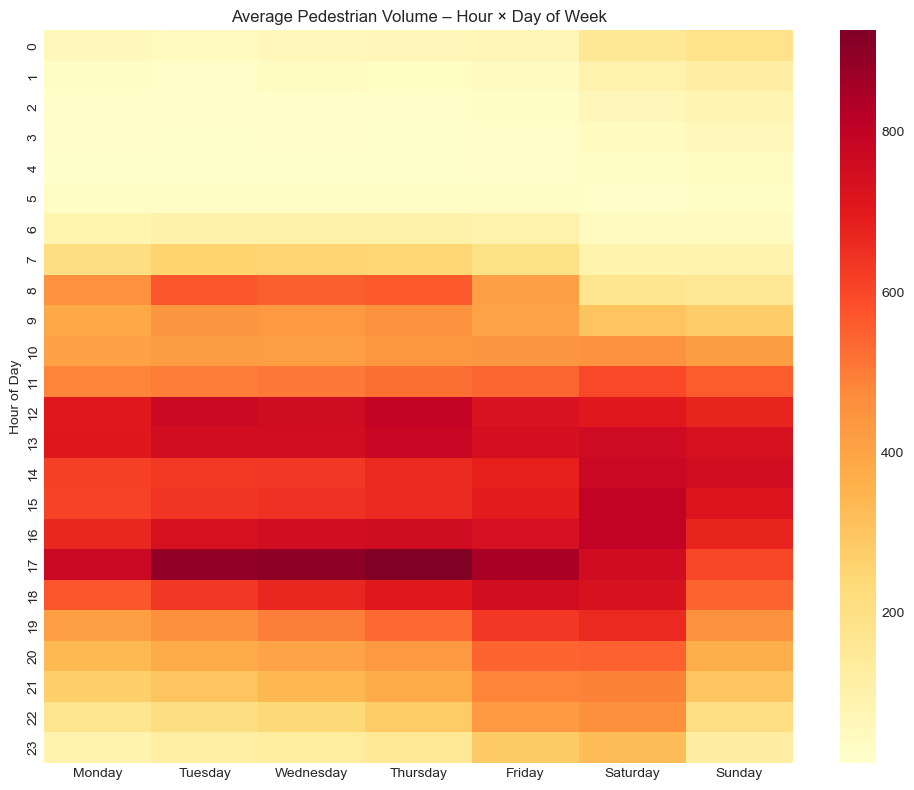

In [36]:
pivot = df.pivot_table(
    values='pedestriancount',
    index='hourday',
    columns='day_name',
    aggfunc='mean'
)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(columns=[d for d in day_order if d in pivot.columns])

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title('Average Pedestrian Volume – Hour × Day of Week')
plt.ylabel('Hour of Day')
plt.xlabel('')
plt.tight_layout()
plt.show()

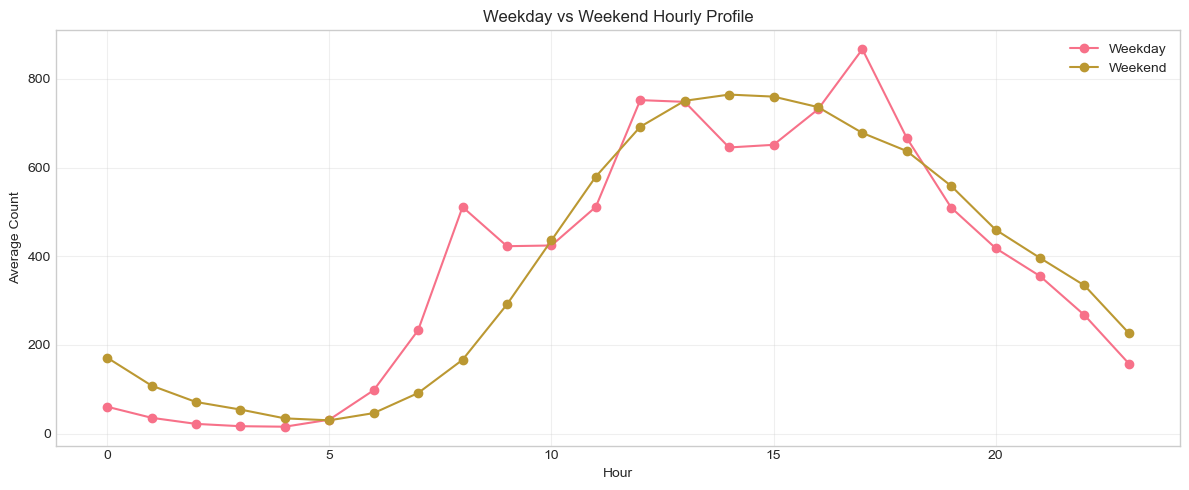

In [37]:
plt.figure(figsize=(12, 5))
for label, subset in df.groupby('is_weekend'):
    avg = subset.groupby('hourday')['pedestriancount'].mean()
    avg.plot(label='Weekend' if label else 'Weekday', marker='o')
plt.title('Weekday vs Weekend Hourly Profile')
plt.xlabel('Hour')
plt.ylabel('Average Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

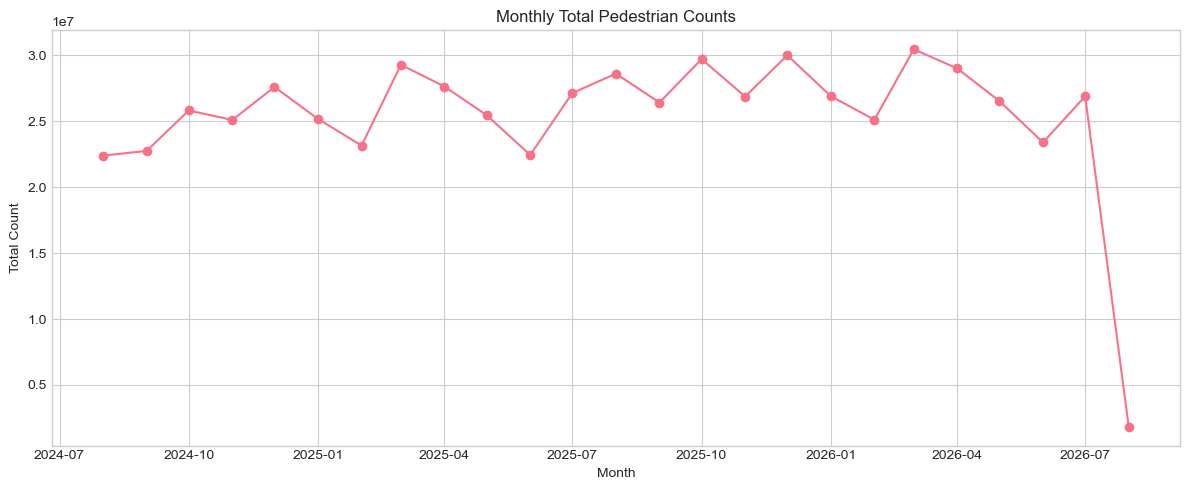

In [38]:
monthly = df.groupby(['year', 'month'])['pedestriancount'].sum().reset_index()
monthly['year_month'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

plt.figure(figsize=(12, 5))
plt.plot(monthly['year_month'], monthly['pedestriancount'], marker='o')
plt.title('Monthly Total Pedestrian Counts')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

Top 15 quietest hour × day combinations:
 day_name  hourday      mean  median       std  count
  Tuesday        3 12.744240     8.0 13.713266   7726
  Tuesday        4 12.862642     8.0 13.882957   8001
Wednesday        4 14.921494     9.0 21.781341   8165
 Thursday        4 15.120138     9.0 20.717705   8124
   Monday        4 16.047210     9.0 19.492497   8155
 Thursday        3 16.270965     9.0 31.144354   7894
  Tuesday        2 16.443830    10.0 19.547233   7958
   Monday        3 16.482497    10.0 20.542841   7913
Wednesday        3 16.529753     9.0 35.951702   7747
   Friday        4 18.321022    11.0 21.881971   8258
   Monday        2 20.808125    12.0 26.750750   8172
   Friday        3 20.849733    12.0 25.427004   8059
Wednesday        2 22.072709    11.0 62.169929   8087
 Thursday        2 22.607037    12.0 55.793563   8100
 Saturday        5 26.296209    16.0 35.798171   8862


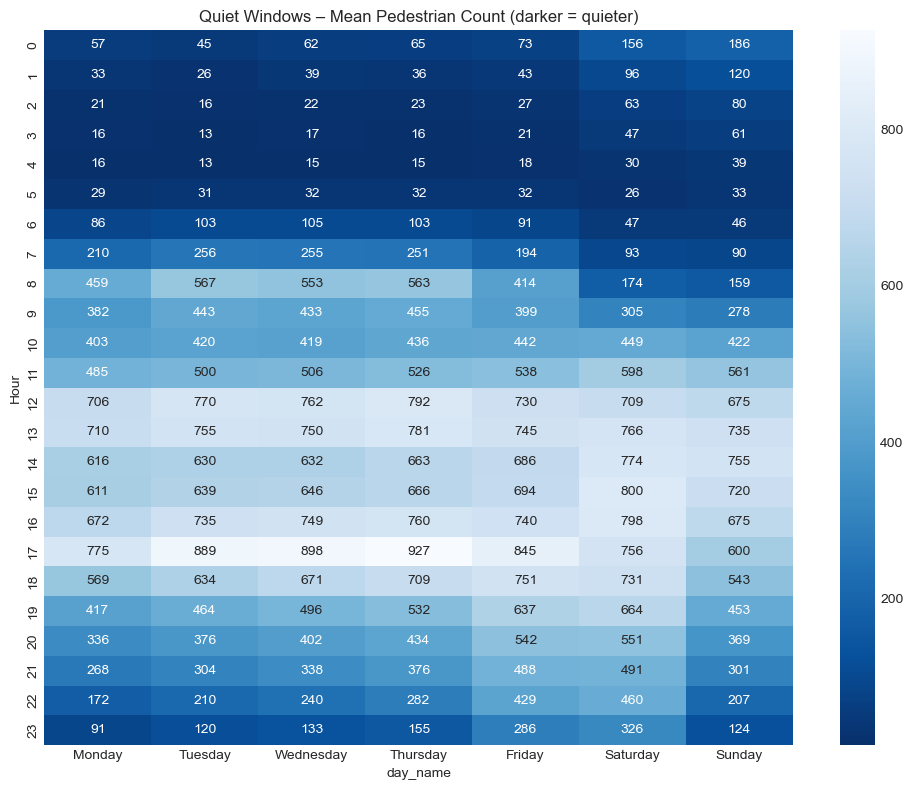

In [39]:
quiet = (df.groupby(['day_name', 'hourday'])['pedestriancount']
           .agg(['mean', 'median', 'std', 'count'])
           .reset_index())


quiet = quiet.sort_values('mean')

print("Top 15 quietest hour × day combinations:")
print(quiet.head(15).to_string(index=False))


quiet_pivot = quiet.pivot(index='hourday', columns='day_name', values='mean')
quiet_pivot = quiet_pivot.reindex(columns=day_order)

plt.figure(figsize=(10, 8))
sns.heatmap(quiet_pivot, cmap='Blues_r', annot=True, fmt='.0f')
plt.title('Quiet Windows – Mean Pedestrian Count (darker = quieter)')
plt.ylabel('Hour')
plt.tight_layout()


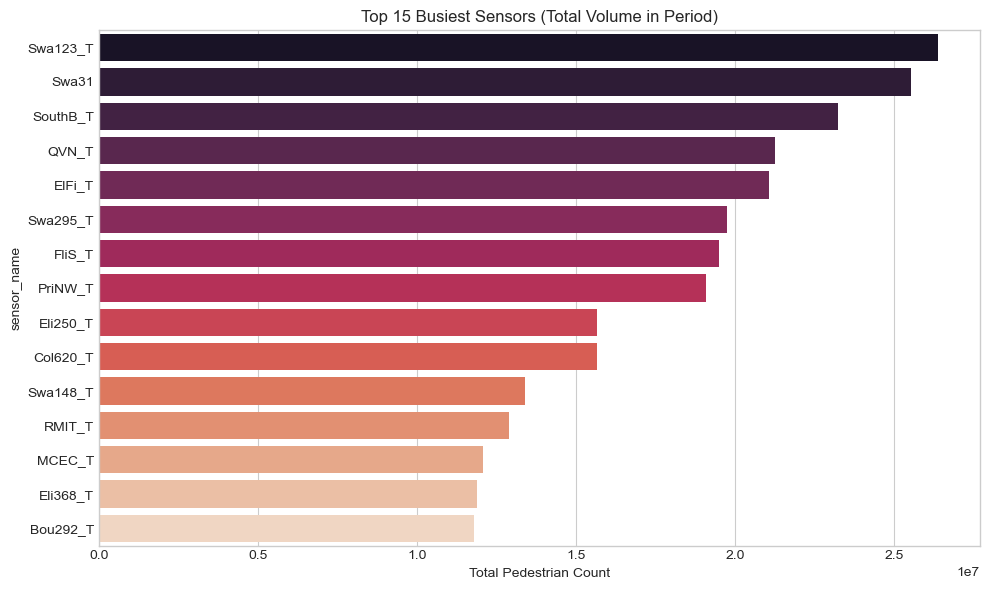

In [40]:
top_sensors = (df.groupby('sensor_name')['pedestriancount']
                 .sum()
                 .sort_values(ascending=False)
                 .head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_sensors.values, y=top_sensors.index, palette='rocket')
plt.title('Top 15 Busiest Sensors (Total Volume in Period)')
plt.xlabel('Total Pedestrian Count')
plt.tight_layout()
plt.show()

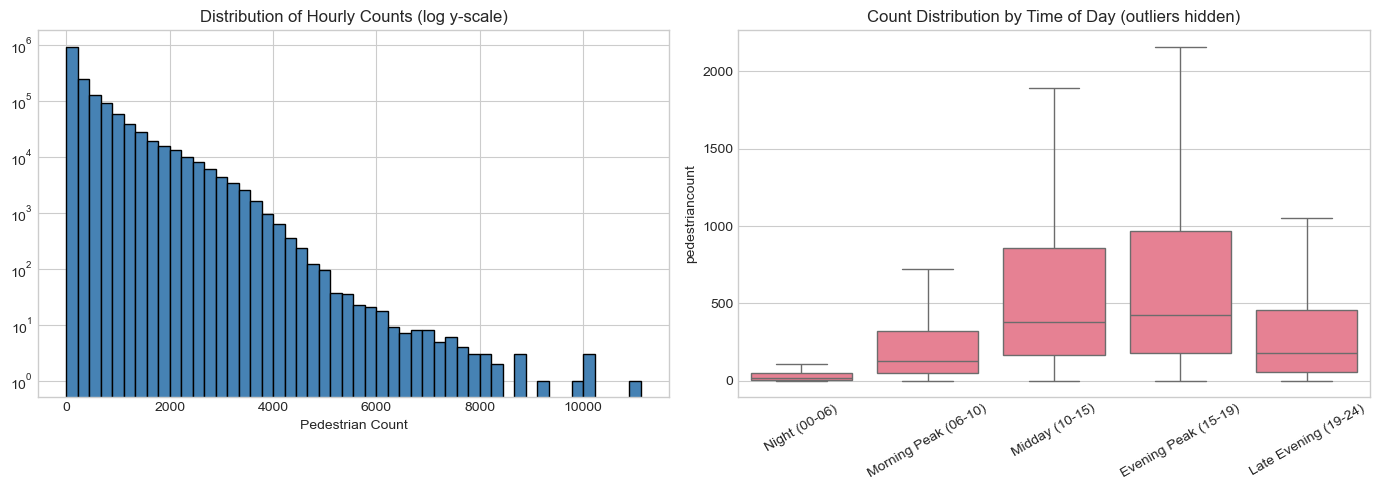

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['pedestriancount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Distribution of Hourly Counts (log y-scale)')
axes[0].set_xlabel('Pedestrian Count')


order = ['Night (00-06)', 'Morning Peak (06-10)', 'Midday (10-15)',
         'Evening Peak (15-19)', 'Late Evening (19-24)']
sns.boxplot(data=df, x='time_bucket', y='pedestriancount',
            order=order, ax=axes[1], showfliers=False)
axes[1].set_title('Count Distribution by Time of Day (outliers hidden)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [42]:

baseline = (df.groupby(['location_id', 'dayofweek', 'hourday'])['pedestriancount']
              .agg(mean_hist='mean', std_hist='std')
              .reset_index())

df_alert = df.merge(baseline, on=['location_id', 'dayofweek', 'hourday'], how='left')

df_alert['zscore'] = (df_alert['pedestriancount'] - df_alert['mean_hist']) / (df_alert['std_hist'] + 1e-6)
df_alert['high_alert'] = df_alert['zscore'] > 3          # >3σ above normal
df_alert['low_alert']  = df_alert['zscore'] < -2         # unusually quiet

print(f"High-volume alerts  (>3σ): {df_alert['high_alert'].sum():,}")
print(f"Unusually quiet alerts:   {df_alert['low_alert'].sum():,}")

print("\nSample recent high-volume alerts:")
print(df_alert[df_alert['high_alert']]
        [['datetime', 'sensor_name', 'pedestriancount', 'mean_hist', 'zscore']]
        .sort_values('datetime', ascending=False)
        .head(10)
        .to_string(index=False))

High-volume alerts  (>3σ): 15,898
Unusually quiet alerts:   25,004

Sample recent high-volume alerts:
           datetime   sensor_name  pedestriancount   mean_hist   zscore
2026-08-02 19:00:00      Bou688_T             1277  602.466019 3.229176
2026-08-02 15:00:00  BirFed1120_T             1992  313.640777 4.234449
2026-08-02 12:00:00      KenMac_T              213  105.733333 3.258679
2026-08-02 11:00:00 EntPark1671_T               36   12.628571 3.301249
2026-08-02 09:00:00 EntPark1671_T               45    8.076923 6.459502
2026-08-02 03:00:00         UM3_T               17    3.646341 4.273903
2026-08-02 02:00:00      FLDegC_T               39    9.019802 3.870439
2026-08-02 02:00:00        RMIT_T              226  107.184466 3.007913
2026-08-01 22:00:00      Bou688_T             2215  760.519608 3.051102
2026-08-01 16:00:00     Spen161_T             2336 1096.490385 3.065770


In [43]:
daily.to_csv("daily_totals.csv", index=False)
hourly_avg.to_csv("hourly_average_profile.csv")
quiet.to_csv("quiet_windows.csv", index=False)

print("Aggregates saved.")
print("\nNotebook complete – data is wrangled, preprocessed and visualised.")

Aggregates saved.

Notebook complete – data is wrangled, preprocessed and visualised.


In [44]:
import folium
from folium.plugins import MarkerCluster, HeatMap
from collections import Counter

In [45]:
URL = (
    "https://data.melbourne.vic.gov.au/api/v2/catalog/datasets/"
    "landmarks-and-places-of-interest-including-schools-theatres-health-services-spor/"
    "exports/csv?delimiter=,"
)

df = pd.read_csv(URL)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(10)

Shape: (242, 4)

Columns: ['theme', 'sub_theme', 'feature_name', 'co_ordinates']


,theme,sub_theme,feature_name,co_ordinates
0,Vacant Land,Current Construction Site - Commercial,Railway Good Shed No 2,"-37.8211371302179, 144.951378883631"
1,Transport,Railway Station,Parliament Railway Station,"-37.8116061787171, 144.973017263156"
2,Leisure/Recreation,Informal Outdoor Facility (Park/Garden/Reserve),North Melbourne Recreation Reserve,"-37.7988345257153, 144.941452061463"
3,Leisure/Recreation,Informal Outdoor Facility (Park/Garden/Reserve),Princes Park,"-37.7870161727156, 144.961115214367"
4,Office,Office,Donor Tissue Bank of Victoria,"-37.8248231859563, 144.965169035668"
5,Transport,Railway Station,Melbourne Central Railway Station,"-37.8100167030855, 144.963789344893"
6,Leisure/Recreation,Informal Outdoor Facility (Park/Garden/Reserve),Argyle Square,"-37.8031480577285, 144.965761295089"
7,Leisure/Recreation,Major Sports & Recreation Facility,Westpac Centre,"-37.8242456858593, 144.979720306309"
8,Education Centre,School - Primary and Secondary Education,Melbourne Girls Grammar School,"-37.8315364518803, 144.985089428348"
9,Health Services,Medical Services,Mercy Private Hospital,"-37.811896809802, 144.984435746587"


In [46]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Rows          : {df.shape[0]}")
print(f"Columns       : {df.shape[1]}")
print(f"Memory        : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 70)
print("THEME DISTRIBUTION")
print("=" * 70)
print(df['theme'].value_counts())

print("\n" + "=" * 70)
print("TOP SUB-THEMES")
print("=" * 70)
print(df['sub_theme'].value_counts().head(15))

DATASET OVERVIEW
Rows          : 242
Columns       : 4
Memory        : 68.4 KB

Dtypes:
theme           object
sub_theme       object
feature_name    object
co_ordinates    object
dtype: object

Missing values:
theme           0
sub_theme       0
feature_name    0
co_ordinates    0
dtype: int64

Duplicate rows: 0

THEME DISTRIBUTION
theme
Leisure/Recreation                      63
Place Of Assembly                       40
Place of Worship                        31
Transport                               26
Community Use                           21
Education Centre                        13
Office                                  11
Health Services                         11
Mixed Use                               11
Purpose Built                            4
Vacant Land                              3
Retail                                   3
Residential Accommodation                2
Warehouse/Store                          1
Industrial                               1
Specialist Res

In [47]:

df.columns = df.columns.str.strip().str.lower()


for col in ['theme', 'sub_theme', 'feature_name']:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(['nan', 'None', ''], np.nan)

def parse_coords(val):
    try:
        if pd.isna(val):
            return np.nan, np.nan
        # Handle both string "lat, lon" and already-parsed cases
        s = str(val).replace('"', '').strip()
        parts = [p.strip() for p in s.split(',')]
        if len(parts) == 2:
            return float(parts[0]), float(parts[1])
        return np.nan, np.nan
    except Exception:
        return np.nan, np.nan
coords = df['co_ordinates'].apply(parse_coords)
df['latitude']  = coords.apply(lambda x: x[0])
df['longitude'] = coords.apply(lambda x: x[1])

df = df.dropna(subset=['latitude', 'longitude', 'feature_name'])

MELB_BOUNDS = {
    'lat_min': -37.90, 'lat_max': -37.75,
    'lon_min': 144.85, 'lon_max': 145.05
}
df['in_melbourne'] = (
    (df['latitude']  >= MELB_BOUNDS['lat_min']) &
    (df['latitude']  <= MELB_BOUNDS['lat_max']) &
    (df['longitude'] >= MELB_BOUNDS['lon_min']) &
    (df['longitude'] <= MELB_BOUNDS['lon_max'])
)
print(f"Points inside approximate Melbourne bounds: {df['in_melbourne'].sum()} / {len(df)}")

df = df[df['in_melbourne']].copy()

print(f"\nCleaned shape: {df.shape}")
df.head()

Points inside approximate Melbourne bounds: 242 / 242

Cleaned shape: (242, 7)


,theme,sub_theme,feature_name,co_ordinates,latitude,longitude,in_melbourne
0,Vacant Land,Current Construction Site - Commercial,Railway Good Shed No 2,"-37.8211371302179, 144.951378883631",-37.821137,144.951379,True
1,Transport,Railway Station,Parliament Railway Station,"-37.8116061787171, 144.973017263156",-37.811606,144.973017,True
2,Leisure/Recreation,Informal Outdoor Facility (Park/Garden/Reserve),North Melbourne Recreation Reserve,"-37.7988345257153, 144.941452061463",-37.798835,144.941452,True
3,Leisure/Recreation,Informal Outdoor Facility (Park/Garden/Reserve),Princes Park,"-37.7870161727156, 144.961115214367",-37.787016,144.961115,True
4,Office,Office,Donor Tissue Bank of Victoria,"-37.8248231859563, 144.965169035668",-37.824823,144.965169,True


In [48]:
SENSORY_REFUGE_THEMES = [
    'Leisure/Recreation',      # parks, gardens
    'Place of Worship',
    'Health Services',
    'Community Use',
    'Education Centre'         # libraries often sit here or under Community Use
]

SENSORY_REFUGE_SUBTHEMES = [
    'Informal Outdoor Facility (Park/Garden/Reserve)',
    'Art Gallery/Museum',
    'Church',
    'Public Hospital',
    'Library',                 # if present
    'Public Buildings'
]

df['is_sensory_refuge'] = (
    df['theme'].isin(SENSORY_REFUGE_THEMES) |
    df['sub_theme'].isin(SENSORY_REFUGE_SUBTHEMES)
)

def broad_category(row):
    t = str(row['theme']).lower()
    st = str(row['sub_theme']).lower()
    if 'park' in st or 'garden' in st or 'reserve' in st or 'leisure' in t:
        return 'Parks & Open Space'
    if 'worship' in t or 'church' in st:
        return 'Places of Worship'
    if 'health' in t or 'hospital' in st:
        return 'Health Services'
    if 'gallery' in st or 'museum' in st or 'theatre' in st:
        return 'Arts & Culture'
    if 'school' in st or 'education' in t or 'university' in st or 'tertiary' in st:
        return 'Education'
    if 'sport' in st:
        return 'Sports Facilities'
    if 'transport' in t or 'station' in st:
        return 'Transport'
    if 'retail' in t or 'office' in t or 'mixed' in t:
        return 'Retail / Commercial'
    return 'Other'

df['broad_category'] = df.apply(broad_category, axis=1)

# 4.3 Approximate CBD flag
CBD_BOUNDS = {
    'lat_min': -37.825, 'lat_max': -37.805,
    'lon_min': 144.955, 'lon_max': 144.980
}
df['in_cbd'] = (
    (df['latitude']  >= CBD_BOUNDS['lat_min']) &
    (df['latitude']  <= CBD_BOUNDS['lat_max']) &
    (df['longitude'] >= CBD_BOUNDS['lon_min']) &
    (df['longitude'] <= CBD_BOUNDS['lon_max'])
)

print("Feature engineering complete")
print(f"\nSensory refuge candidates: {df['is_sensory_refuge'].sum()}")
print(f"Inside CBD: {df['in_cbd'].sum()}")
print("\nBroad category counts:")
print(df['broad_category'].value_counts())

Feature engineering complete

Sensory refuge candidates: 159
Inside CBD: 107

Broad category counts:
broad_category
Parks & Open Space     70
Other                  35
Arts & Culture         34
Places of Worship      31
Transport              29
Retail / Commercial    18
Education              13
Health Services        11
Sports Facilities       1
Name: count, dtype: int64


In [49]:
print("=" * 70)
print("THEME × SUB-THEME CROSS-TAB (top combinations)")
print("=" * 70)
cross = (df.groupby(['theme', 'sub_theme'])
           .size()
           .reset_index(name='count')
           .sort_values('count', ascending=False))
print(cross.head(20).to_string(index=False))

print("\n" + "=" * 70)
print("SENSORY REFUGE PLACES")
print("=" * 70)
refuge = df[df['is_sensory_refuge']][['feature_name', 'theme', 'sub_theme', 'broad_category']]
print(refuge.sort_values('broad_category').to_string(index=False))

THEME × SUB-THEME CROSS-TAB (top combinations)
             theme                                       sub_theme  count
Leisure/Recreation Informal Outdoor Facility (Park/Garden/Reserve)     37
  Place of Worship                                          Church     30
         Transport                                 Railway Station     23
 Place Of Assembly                              Art Gallery/Museum     19
 Place Of Assembly                                    Theatre Live     15
Leisure/Recreation              Major Sports & Recreation Facility     14
     Community Use                                Public Buildings     13
            Office                                          Office     11
   Health Services                                 Public Hospital      7
         Mixed Use                           Retail/Office/Carpark      5
  Education Centre                           Tertiary (University)      4
Leisure/Recreation  Outdoor Recreation Facility (Zoo, Golf Course

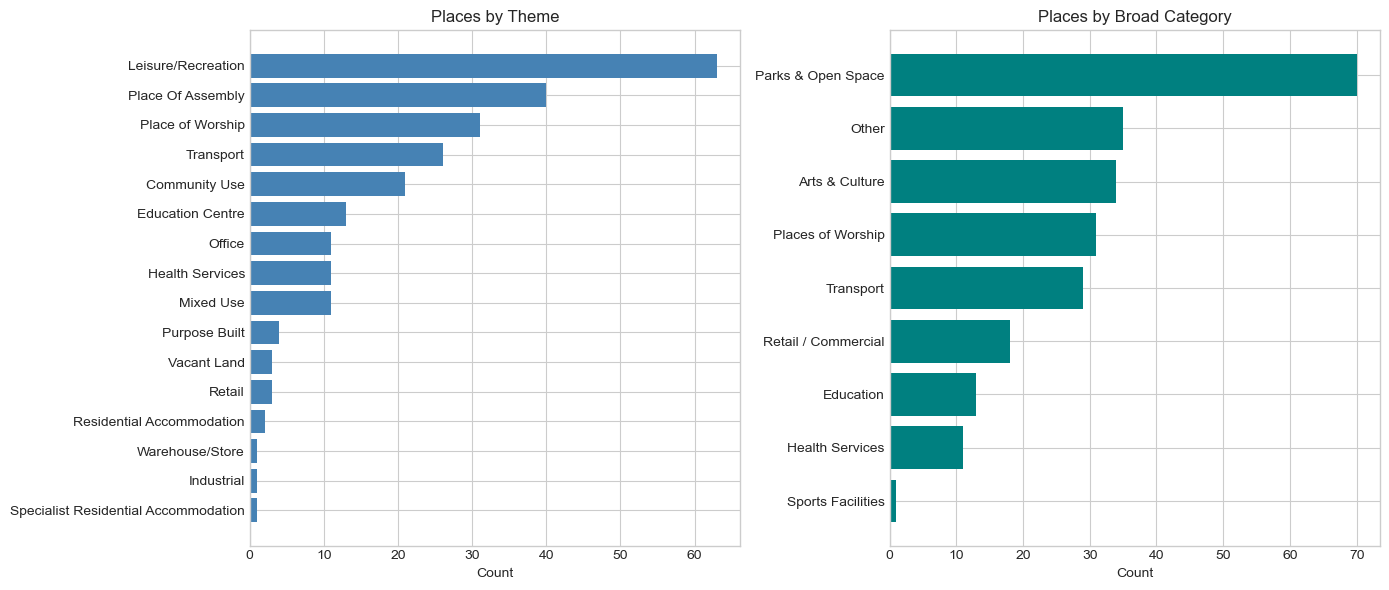

In [50]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

theme_counts = df['theme'].value_counts()
axes[0].barh(theme_counts.index[::-1], theme_counts.values[::-1], color='steelblue')
axes[0].set_title('Places by Theme')
axes[0].set_xlabel('Count')

cat_counts = df['broad_category'].value_counts()
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='teal')
axes[1].set_title('Places by Broad Category')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

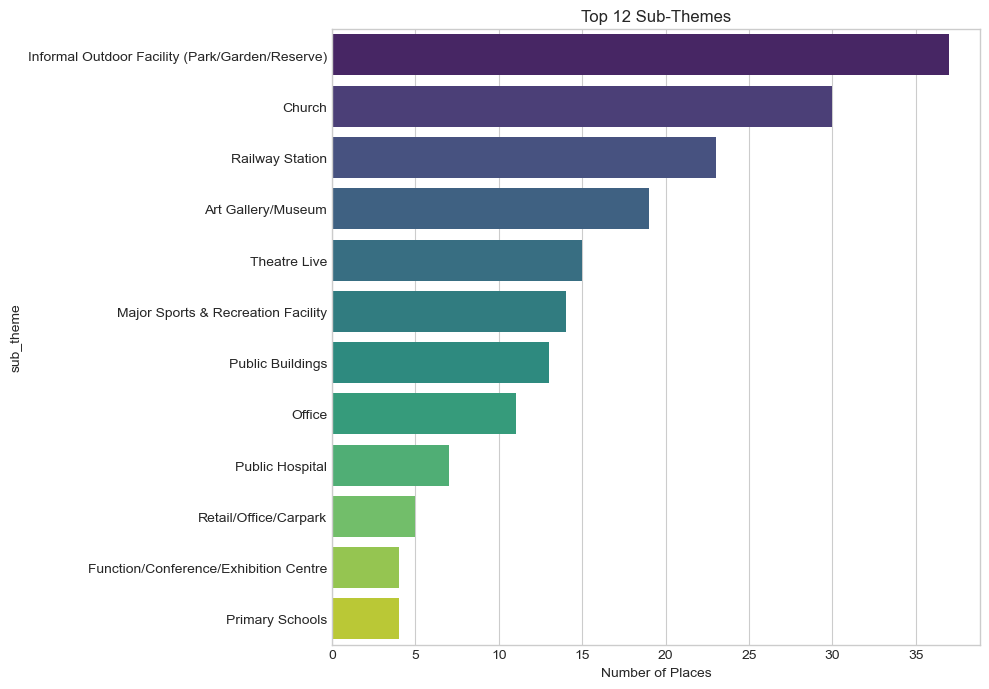

In [51]:

plt.figure(figsize=(10, 7))
top_sub = df['sub_theme'].value_counts().head(12)
sns.barplot(x=top_sub.values, y=top_sub.index, palette='viridis')
plt.title('Top 12 Sub-Themes')
plt.xlabel('Number of Places')
plt.tight_layout()
plt.show()

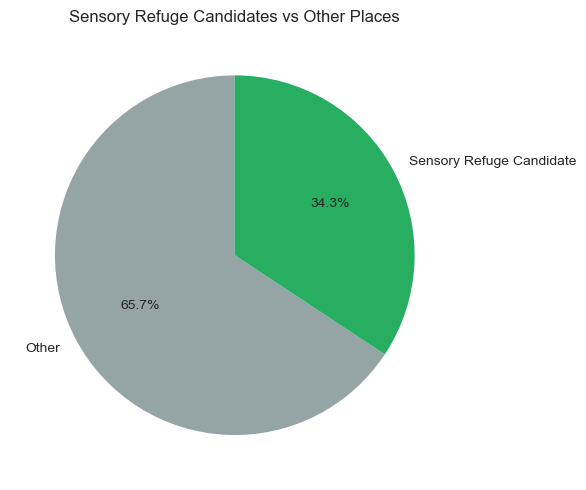

In [52]:

plt.figure(figsize=(6, 5))
df['is_sensory_refuge'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Other', 'Sensory Refuge Candidate'],
    colors=['#95a5a6', '#27ae60'],
    startangle=90
)
plt.title('Sensory Refuge Candidates vs Other Places')
plt.ylabel('')
plt.tight_layout()
plt.show()

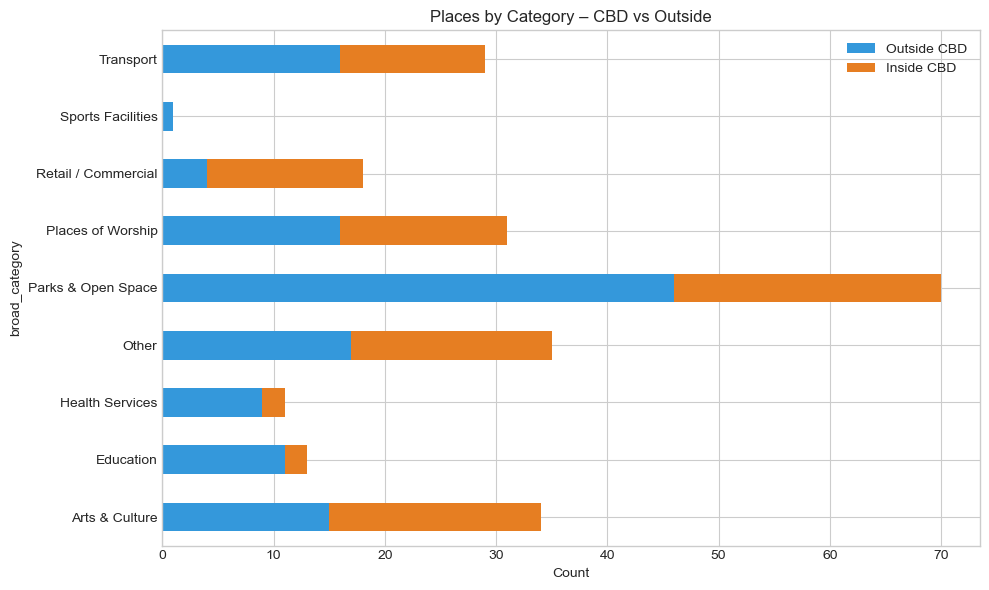

In [53]:
cbd_cat = pd.crosstab(df['broad_category'], df['in_cbd'])
cbd_cat.columns = ['Outside CBD', 'Inside CBD']

cbd_cat.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#3498db', '#e67e22'])
plt.title('Places by Category – CBD vs Outside')
plt.xlabel('Count')
plt.legend(title='')
plt.tight_layout()
plt.show()

In [54]:
COLOUR_MAP = {
    'Parks & Open Space': 'green',
    'Places of Worship' : 'purple',
    'Health Services'   : 'red',
    'Arts & Culture'    : 'orange',
    'Education'         : 'blue',
    'Sports Facilities' : 'darkgreen',
    'Transport'         : 'gray',
    'Retail / Commercial': 'cadetblue',
    'Other'             : 'black'
}

m = folium.Map(location=[-37.8136, 144.9631], zoom_start=13, tiles='CartoDB positron')

marker_cluster = MarkerCluster().add_to(m)

for _, row in df.iterrows():
    colour = COLOUR_MAP.get(row['broad_category'], 'black')
    popup_html = f"""
    <b>{row['feature_name']}</b><br>
    Theme: {row['theme']}<br>
    Sub-theme: {row['sub_theme']}<br>
    Category: {row['broad_category']}<br>
    Sensory refuge: {'Yes' if row['is_sensory_refuge'] else 'No'}
    """
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color=colour,
        fill=True,
        fill_opacity=0.75,
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=row['feature_name']
    ).add_to(marker_cluster)

# Optional CBD rectangle
folium.Rectangle(
    bounds=[[CBD_BOUNDS['lat_min'], CBD_BOUNDS['lon_min']],
            [CBD_BOUNDS['lat_max'], CBD_BOUNDS['lon_max']]],
    color='orange', weight=2, fill=False, popup='Approx. CBD'
).add_to(m)

# Simple legend
legend_html = """
<div style="position:fixed; bottom:40px; left:40px; z-index:1000;
            background:white; padding:10px 14px; border:2px solid #555;
            border-radius:6px; font-size:13px; line-height:1.5;">
<b>Category</b><br>
<span style="color:green;">●</span> Parks & Open Space<br>
<span style="color:purple;">●</span> Places of Worship<br>
<span style="color:red;">●</span> Health Services<br>
<span style="color:orange;">●</span> Arts & Culture<br>
<span style="color:blue;">●</span> Education<br>
<span style="color:darkgreen;">●</span> Sports<br>
<span style="color:gray;">●</span> Transport<br>
<span style="color:cadetblue;">●</span> Retail / Commercial
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m  # display
# m.save('melbourne_landmarks_map.html')

In [55]:

m_refuge = folium.Map(location=[-37.8136, 144.9631], zoom_start=13, tiles='CartoDB positron')

refuge_df = df[df['is_sensory_refuge']]

for _, row in refuge_df.iterrows():
    colour = COLOUR_MAP.get(row['broad_category'], 'green')
    popup_html = f"""
    <b>{row['feature_name']}</b><br>
    {row['sub_theme']}<br>
    Category: {row['broad_category']}
    """
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=row['feature_name'],
        icon=folium.Icon(color=colour, icon='info-sign')
    ).add_to(m_refuge)

m_refuge
# m_refuge.save('melbourne_sensory_refuges.html')

In [56]:

m_heat = folium.Map(location=[-37.8136, 144.9631], zoom_start=13, tiles='CartoDB dark_matter')

heat_data = df[['latitude', 'longitude']].dropna().values.tolist()
HeatMap(heat_data, radius=18, blur=15, max_zoom=14).add_to(m_heat)

m_heat

In [57]:
df_clean = df[[
    'feature_name', 'theme', 'sub_theme', 'broad_category',
    'is_sensory_refuge', 'in_cbd',
    'latitude', 'longitude'
]].copy()

df_clean.to_csv('melbourne_landmarks_clean.csv', index=False)

# Sensory refuges only
df_clean[df_clean['is_sensory_refuge']].to_csv(
    'melbourne_sensory_refuges.csv', index=False
)

print("Files saved:")
print("  - melbourne_landmarks_clean.csv")
print("  - melbourne_sensory_refuges.csv")
print(f"\nTotal places     : {len(df_clean)}")
print(f"Sensory refuges  : {df_clean['is_sensory_refuge'].sum()}")
print(f"Inside CBD       : {df_clean['in_cbd'].sum()}")

Files saved:
  - melbourne_landmarks_clean.csv
  - melbourne_sensory_refuges.csv

Total places     : 242
Sensory refuges  : 159
Inside CBD       : 107


In [58]:
pip install streamlit pandas numpy matplotlib seaborn plotly folium streamlit-folium

   ---------------------------------------- 0.0/536.7 kB ? eta -:--:--
   ------------------- -------------------- 262.1/536.7 kB ? eta -:--:--
   ---------------------------------------- 536.7/536.7 kB 8.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
